# Lifecycle carbon footprint of electricity, applied to China's grid

Lifecycle emissions per technology from **IPCC AR5 WGIII Annex III** (2014, Table A.III.2),
China's generation mix from **Our World in Data** (Ember and the Energy Institute), and the
official **2023 grid emission factors** (生态环境部、国家统计局, published 2025-12-31).
Every number below is read from a table in `data/` that records its source.

In [1]:
import sys
sys.path.insert(0, "../scripts")
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import lca_calculation as m

plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 150, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.facecolor": "white"})
OUT = Path("../outputs"); OUT.mkdir(exist_ok=True)

ar5, mix, grid = m.load_ar5(), m.load_mix(), m.load_grid_factors()
series = m.intensity_series()
G = {r: grid.loc[r, "kgco2_per_kwh"] * 1000 for r in ["National", "South", "North"]}  # g/kWh
REGION_LABEL = {"National": "National average", "South": "South grid (GBA)", "North": "North grid"}
print(f"{len(ar5)} AR5 technologies | mix {mix.index.min()}–{mix.index.max()} | {len(grid)} official grid factors")

11 AR5 technologies | mix 2015–2024 | 7 official grid factors


## 1. Lifecycle emissions by technology

Median with the full min–max range reported in Table A.III.2, on a log scale because the
spread runs from under 4 to 2,200 gCO2eq/kWh. Hydropower's upper bound is methane from
reservoirs in warm climates; AR5 reports it and so does this chart.

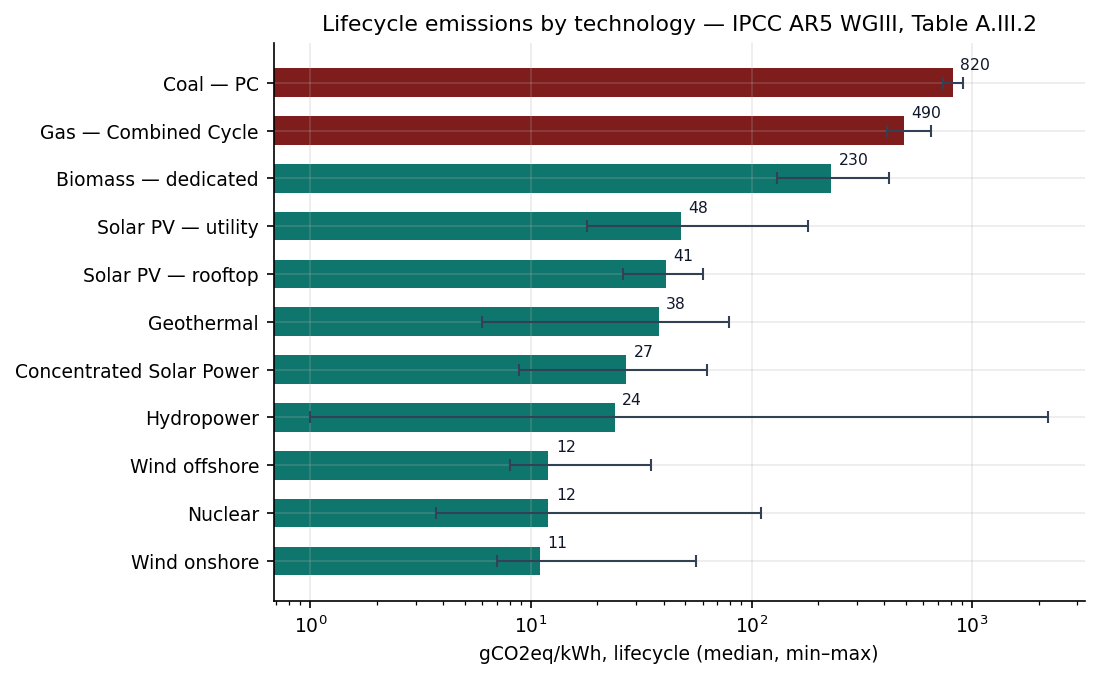

,lifecycle_min,lifecycle_median,lifecycle_max,plant_lifetime_yr
technology,,,,
Wind onshore,7.0,11,56,25.0
Nuclear,3.7,12,110,NaN
Wind offshore,8.0,12,35,25.0
Hydropower,1.0,24,2200,50.0
Concentrated Solar Power,8.8,27,63,NaN
Geothermal,6.0,38,79,NaN
Solar PV — rooftop,26.0,41,60,25.0
Solar PV — utility,18.0,48,180,25.0
Biomass — dedicated,130.0,230,420,NaN


In [2]:
t = ar5.sort_values("lifecycle_median")
fossil = t.index.str.startswith(("Coal", "Gas"))
fig, ax = plt.subplots(figsize=(7.4, 4.6))
y = np.arange(len(t))
ax.barh(y, t["lifecycle_median"], color=np.where(fossil, "#7f1d1d", "#0f766e"), height=0.6)
ax.errorbar(t["lifecycle_median"], y,
            xerr=[t["lifecycle_median"] - t["lifecycle_min"], t["lifecycle_max"] - t["lifecycle_median"]],
            fmt="none", ecolor="#334155", capsize=3, linewidth=1)
for yi, v in zip(y, t["lifecycle_median"]):
    ax.text(v * 1.08, yi + 0.28, f"{v:g}", fontsize=7.5, color="#0f172a")
ax.set_yticks(y); ax.set_yticklabels(t.index)
ax.set_xscale("log"); ax.set_xlabel("gCO2eq/kWh, lifecycle (median, min–max)")
ax.set_title("Lifecycle emissions by technology — IPCC AR5 WGIII, Table A.III.2", fontsize=10.5)
fig.tight_layout(); fig.savefig(OUT / "lifecycle_comparison.png", bbox_inches="tight"); plt.show()
t[["lifecycle_min", "lifecycle_median", "lifecycle_max", "plant_lifetime_yr"]]

## 2. China's generation mix and its lifecycle intensity, 2015–2024

Shares sum to 100% in every year. Oil (0.6–0.9%) has no row in Table A.III.2 and is excluded
from the weighting; the covered share is reported. This is a **lifecycle** intensity — it
includes coal mining and gas-supply methane — so it runs higher than the official
operational factor (0.5306 kg/kWh for 2023) and the two should not be compared directly.

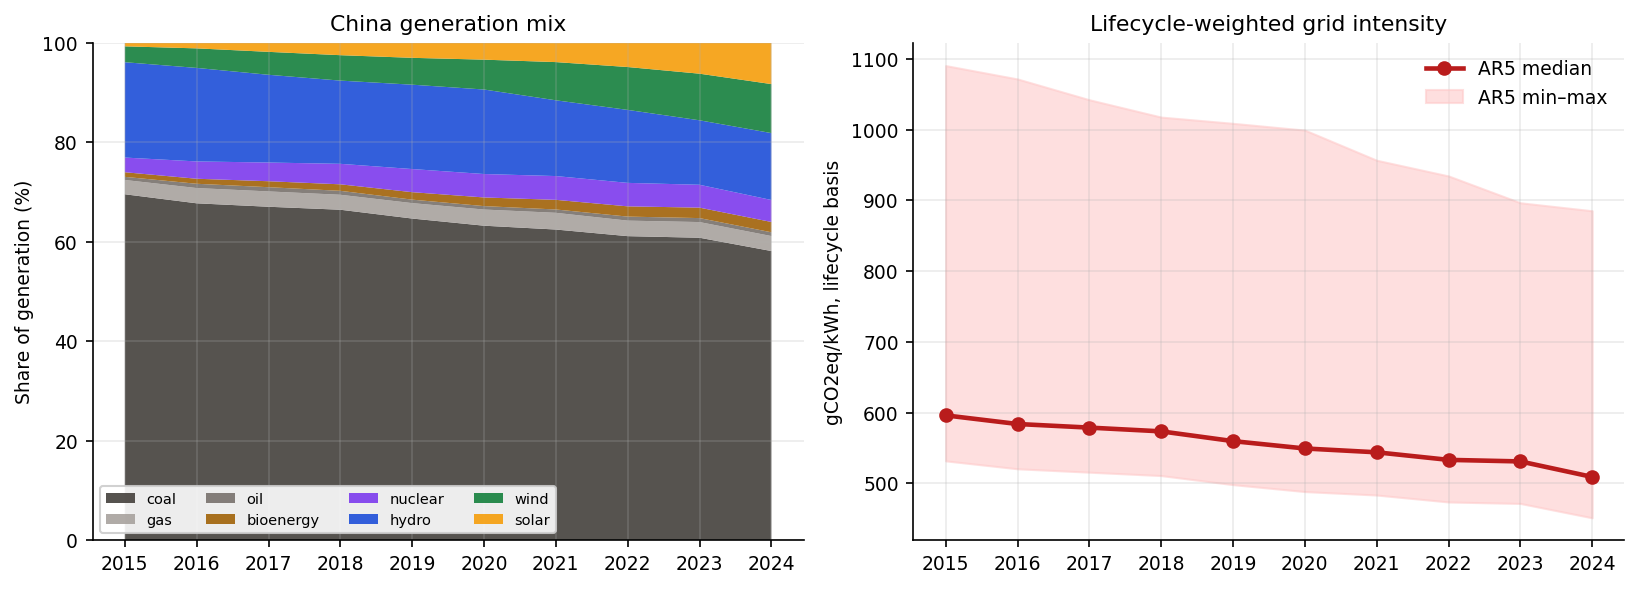

,year,coal_share_pct,non_fossil_share_pct,intensity_median,intensity_min,intensity_max,covered_share_pct
0,2015,69.59,26.92,596.2,531.9,1090.6,99.38
1,2016,67.77,28.30,584.0,520.7,1071.7,99.14
2,2017,67.08,28.99,578.9,515.9,1042.3,99.15
3,2018,66.48,29.74,573.6,511.1,1017.8,99.23
4,2019,64.71,31.49,559.8,498.3,1009.0,99.30
5,2020,63.27,32.80,549.4,488.5,999.4,99.32
6,2021,62.50,33.46,544.0,483.6,956.8,99.32
7,2022,61.17,34.90,533.3,473.8,934.6,99.19
8,2023,60.85,35.21,531.1,471.7,896.7,99.21
9,2024,58.18,38.07,509.2,451.4,885.4,99.26


In [3]:
order = ["coal", "gas", "oil", "bioenergy", "nuclear", "hydro", "wind", "solar"]
colours = ["#44403c", "#a8a29e", "#78716c", "#a16207", "#7c3aed", "#1d4ed8", "#15803d", "#f59e0b"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].stackplot(mix.index, *[mix[c] for c in order], labels=order, colors=colours, alpha=0.9)
axes[0].set_ylim(0, 100); axes[0].set_ylabel("Share of generation (%)")
axes[0].set_title("China generation mix", fontsize=10.5)
axes[0].legend(loc="lower left", fontsize=7, ncol=4, framealpha=0.9)
s = series.set_index("year")
axes[1].fill_between(s.index, s["intensity_min"], s["intensity_max"], color="#fecaca", alpha=0.6,
                     label="AR5 min–max")
axes[1].plot(s.index, s["intensity_median"], marker="o", color="#b91c1c", linewidth=2.2, label="AR5 median")
axes[1].set_ylabel("gCO2eq/kWh, lifecycle basis")
axes[1].set_title("Lifecycle-weighted grid intensity", fontsize=10.5); axes[1].legend(frameon=False)
for ax in axes: ax.set_xticks(mix.index)
fig.tight_layout(); fig.savefig(OUT / "grid_decarbonisation.png", bbox_inches="tight"); plt.show()
series

## 3. Official 2023 grid emission factors by region

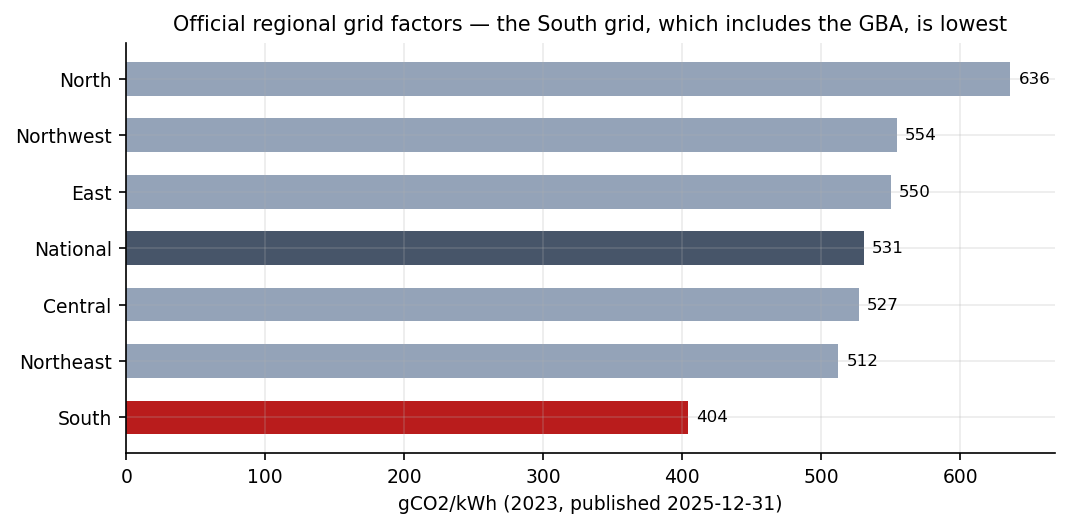

,region,kgco2_per_kwh
region_en,,
South,南方,0.4042
Northeast,东北,0.5122
Central,华中,0.5271
National,全国,0.5306
East,华东,0.5500
Northwest,西北,0.5543
North,华北,0.6361


In [4]:
g = grid.sort_values("kgco2_per_kwh")
fig, ax = plt.subplots(figsize=(7.2, 3.6))
colours = ["#b91c1c" if r == "South" else ("#475569" if r == "National" else "#94a3b8") for r in g.index]
ax.barh(g.index, g["kgco2_per_kwh"] * 1000, color=colours, height=0.6)
for yi, v in enumerate(g["kgco2_per_kwh"] * 1000):
    ax.text(v + 6, yi, f"{v:.0f}", va="center", fontsize=8)
ax.set_xlabel("gCO2/kWh (2023, published 2025-12-31)")
ax.set_title("Official regional grid factors — the South grid, which includes the GBA, is lowest", fontsize=10)
fig.tight_layout(); fig.savefig(OUT / "regional_grid_ef.png", bbox_inches="tight"); plt.show()
g[["region", "kgco2_per_kwh"]]

## 4. Emissions avoided by 100 MW of new renewable capacity

Capacity factors are assumptions — solar 0.16, onshore wind 0.25, offshore wind 0.35 — each
inside AR5's own full-load-hour range for the technology. Tonnage scales linearly with them;
the ratio between regions does not depend on them at all. Displaced emissions use the
official **average** grid factor; displaced generation at the margin is usually fossil, so
this understates what a new plant avoids.

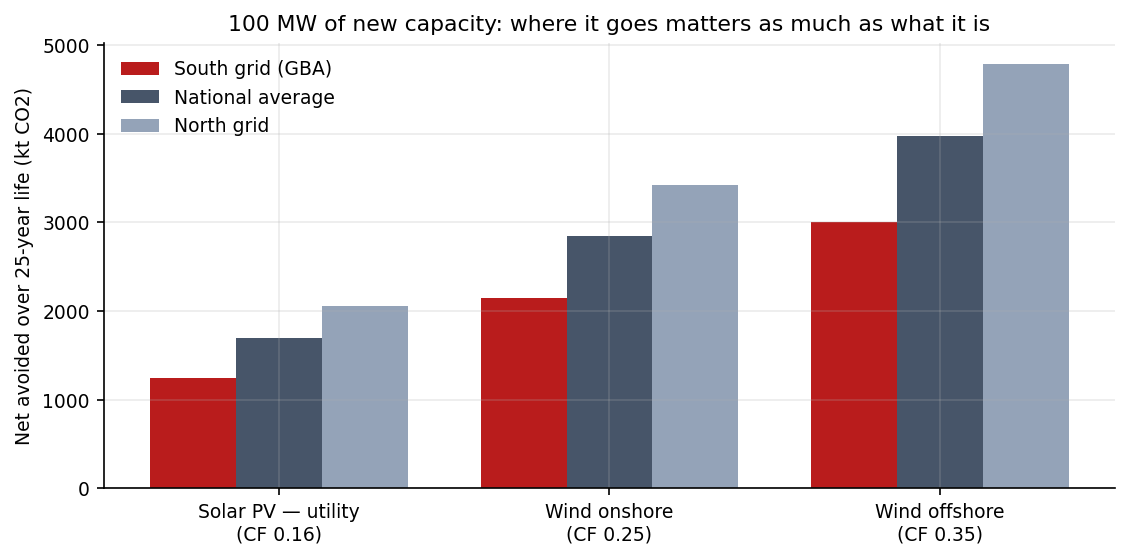

region,National,North,South
technology,,,
Solar PV — utility,67641,82428,49925
Wind offshore,159003,191349,120249
Wind onshore,113792,136897,86111


In [5]:
CF = {"Solar PV — utility": 0.16, "Wind onshore": 0.25, "Wind offshore": 0.35}
rows = [m.avoided_emissions(100, tech, cf, G[r]) | {"region": r} for tech, cf in CF.items() for r in G]
avoided = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(7.6, 3.8))
x = np.arange(len(CF)); w = 0.26
for k, (r, colour) in enumerate(zip(["South", "National", "North"], ["#b91c1c", "#475569", "#94a3b8"])):
    vals = [avoided[(avoided.technology == t) & (avoided.region == r)]["lifetime_net_avoided_t"].iloc[0] / 1000 for t in CF]
    ax.bar(x + (k - 1) * w, vals, w, color=colour, label=REGION_LABEL[r])
ax.set_xticks(x); ax.set_xticklabels([f"{t}\n(CF {cf})" for t, cf in CF.items()])
ax.set_ylabel("Net avoided over 25-year life (kt CO2)")
ax.set_title("100 MW of new capacity: where it goes matters as much as what it is", fontsize=10.5)
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT / "avoided_emissions.png", bbox_inches="tight"); plt.show()
avoided.pivot(index="technology", columns="region", values="net_avoided_t_per_year")

## 5. Carbon payback

Years of operation needed to avoid as much as the plant emitted over its lifecycle:
lifecycle intensity × lifetime ÷ displaced grid factor. Capacity factor cancels out. Error
bars are AR5's min–max for the technology's lifecycle intensity.

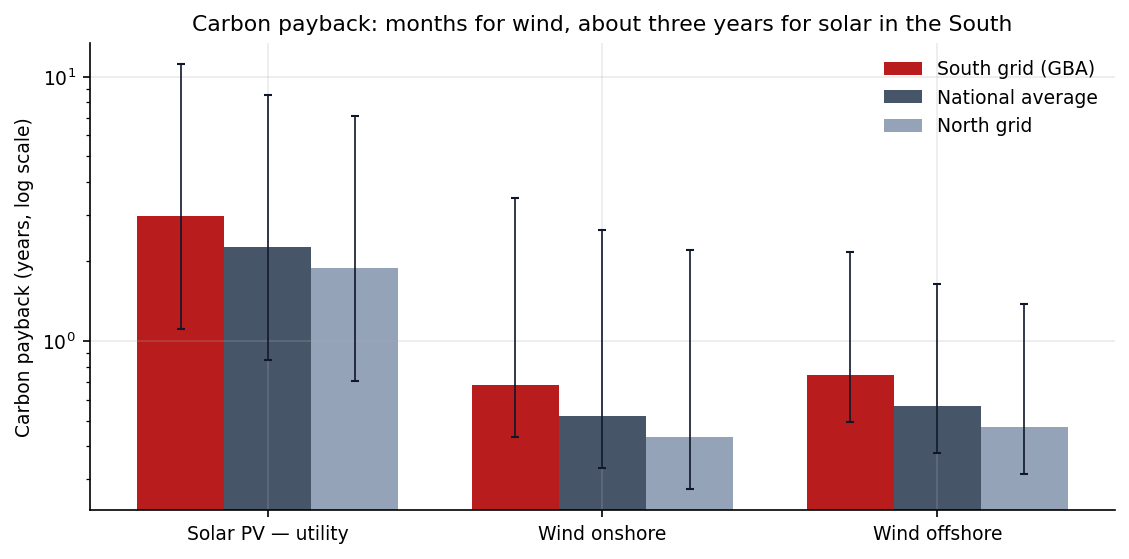

,South,National,North
Solar PV — utility,2.97,2.26,1.89
Wind onshore,0.68,0.52,0.43
Wind offshore,0.74,0.57,0.47


In [6]:
techs = list(CF)
fig, ax = plt.subplots(figsize=(7.6, 3.8))
x = np.arange(len(techs)); w = 0.26
table = {}
for k, (r, colour) in enumerate(zip(["South", "National", "North"], ["#b91c1c", "#475569", "#94a3b8"])):
    med = np.array([m.payback_years(t, G[r]) for t in techs])
    lo = np.array([m.payback_years(t, G[r], "min") for t in techs])
    hi = np.array([m.payback_years(t, G[r], "max") for t in techs])
    table[r] = med
    ax.bar(x + (k - 1) * w, med, w, color=colour, label=REGION_LABEL[r])
    ax.errorbar(x + (k - 1) * w, med, yerr=[med - lo, hi - med], fmt="none", ecolor="#0f172a", capsize=2, linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(techs); ax.set_yscale("log")
ax.set_ylabel("Carbon payback (years, log scale)")
ax.set_title("Carbon payback: months for wind, about three years for solar in the South", fontsize=10.5)
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT / "carbon_payback.png", bbox_inches="tight"); plt.show()
pd.DataFrame(table, index=techs).round(2)

## Conclusions

Generated from the tables above, so they cannot drift from them.

In [7]:
s = series.set_index("year")
coal = ar5.loc["Coal — PC", "lifecycle_median"]
first, last = s.index.min(), s.index.max()
sp = {r: m.avoided_emissions(100, "Solar PV — utility", 0.16, G[r])["net_avoided_t_per_year"] for r in G}
lines = [
    f"- Coal PC is {coal:g} gCO2eq/kWh over its lifecycle — {coal/ar5.loc['Wind onshore','lifecycle_median']:.0f}× onshore wind, "
    f"{coal/ar5.loc['Nuclear','lifecycle_median']:.0f}× nuclear, {coal/ar5.loc['Solar PV — utility','lifecycle_median']:.0f}× utility solar (AR5 medians).",
    f"- China's coal share fell from {s.loc[first,'coal_share_pct']:.1f}% ({first}) to {s.loc[last,'coal_share_pct']:.1f}% ({last}); "
    f"the lifecycle-weighted intensity fell from {s.loc[first,'intensity_median']:.0f} to {s.loc[last,'intensity_median']:.0f} gCO2eq/kWh "
    f"({100*(s.loc[last,'intensity_median']/s.loc[first,'intensity_median']-1):+.1f}%).",
    f"- The South grid's official 2023 factor ({G['South']:.0f} g/kWh) is {100*(1-G['South']/G['North']):.0f}% below the North's ({G['North']:.0f}).",
    f"- 100 MW of utility solar avoids {sp['South']:,} t CO2 a year net in the South and {sp['North']:,} in the North — "
    f"{100*(sp['North']/sp['South']-1):.0f}% more, for the same panels.",
    f"- Carbon payback, South grid: utility solar {m.payback_years('Solar PV — utility', G['South']):.1f} years "
    f"(AR5 range {m.payback_years('Solar PV — utility', G['South'], 'min'):.1f}–{m.payback_years('Solar PV — utility', G['South'], 'max'):.0f}), "
    f"onshore wind {12*m.payback_years('Wind onshore', G['South']):.0f} months.",
]
print("\n".join(lines))

- Coal PC is 820 gCO2eq/kWh over its lifecycle — 75× onshore wind, 68× nuclear, 17× utility solar (AR5 medians).
- China's coal share fell from 69.6% (2015) to 58.2% (2024); the lifecycle-weighted intensity fell from 596 to 509 gCO2eq/kWh (-14.6%).
- The South grid's official 2023 factor (404 g/kWh) is 36% below the North's (636).
- 100 MW of utility solar avoids 49,925 t CO2 a year net in the South and 82,428 in the North — 65% more, for the same panels.
- Carbon payback, South grid: utility solar 3.0 years (AR5 range 1.1–11), onshore wind 8 months.
